# Fase 5 — Clasificación: Detección de Riesgo en Salud Mental

## Objetivo
Construir un modelo de clasificación binaria que identifique estudiantes
con riesgo de salud mental (Riesgo_SM = 1) a partir de variables de
comportamiento, consumo de sustancias y factores sociales.

## Reto técnico
El target presenta un desbalance severo: aproximadamente 86.6% sin riesgo
frente a 13.4% con riesgo (ratio ~6.5:1). Un modelo que prediga siempre
"sin riesgo" tendría 86% de accuracy pero sería clínicamente inútil.
Por eso las métricas principales son F1-Score de la clase minoritaria
y AUC-ROC, no el accuracy.

## Estrategia
- SMOTE (Synthetic Minority Over-sampling Technique) para balancear train
- Dos modelos: Regresión Logística (baseline interpretable) y XGBoost
- Validación cruzada estratificada para evitar sobreestimar rendimiento
- Métricas: F1 clase 1, AUC-ROC, matriz de confusión completa

In [1]:
# ── Imports ────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

# Modelos
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Métricas y validación
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    ConfusionMatrixDisplay
)

# Balanceo
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Rutas
BASE = Path.cwd().parent
DATA = BASE / "data" / "processed"
FIGS = BASE / "reports" / "figures"
MODELS = BASE / "models"

# Semilla global
SEED = 42
np.random.seed(SEED)

print("Librerías cargadas correctamente.")
print(f"  Base del proyecto : {BASE.name}")
print(f"  Data processed    : {DATA.exists()}")
print(f"  Figures           : {FIGS.exists()}")

Librerías cargadas correctamente.
  Base del proyecto : Prediccion-FactoresRiesgo
  Data processed    : True
  Figures           : True


## Carga de artefactos

Se cargan los conjuntos de entrenamiento y prueba generados en la Fase 3 v2.
Para la clasificación se usan exclusivamente los targets de la Tarea B (Riesgo_SM).
Los artefactos de Tarea A (IMC) no se tocan en esta fase.

In [2]:
# ── Carga de artefactos Fase 3 v2 ──────────────────────────
X_train = pd.read_csv(DATA / "X_train_scaled_v2.csv", index_col=0)
X_test  = pd.read_csv(DATA / "X_test_scaled_v2.csv",  index_col=0)

y_train = pd.read_csv(DATA / "y_B_train_v2.csv", index_col=0).squeeze()
y_test  = pd.read_csv(DATA / "y_B_test_v2.csv",  index_col=0).squeeze()

print("Artefactos cargados:")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}  — dtype: {y_train.dtype}")
print(f"  y_test  : {y_test.shape}   — dtype: {y_test.dtype}")
print(f"\nNaN en X_train : {X_train.isnull().sum().sum()}")
print(f"NaN en X_test  : {X_test.isnull().sum().sum()}")
print(f"NaN en y_train : {y_train.isnull().sum()}")
print(f"NaN en y_test  : {y_test.isnull().sum()}")

Artefactos cargados:
  X_train : (1524, 49)
  X_test  : (382, 49)
  y_train : (1524,)  — dtype: float64
  y_test  : (382,)   — dtype: float64

NaN en X_train : 0
NaN en X_test  : 0
NaN en y_train : 0
NaN en y_test  : 0


## Diagnóstico del desbalance de clases

Antes de aplicar SMOTE es necesario cuantificar el desbalance real en los
conjuntos de entrenamiento y prueba por separado.

Un punto crítico: SMOTE **solo se aplica sobre el conjunto de entrenamiento**.
Aplicarlo también sobre test contaminaría la evaluación — el modelo vería
patrones sintéticos que no existen en datos reales.

El ratio de desbalance se define como:
    ratio = n_clase_mayoritaria / n_clase_minoritaria

Un ratio > 3:1 ya justifica técnicas de rebalanceo. Con ~6.5:1 el impacto
sobre F1 de la clase minoritaria es severo si no se corrige.

In [3]:
# ── Diagnóstico de desbalance ───────────────────────────────
def resumen_clases(y, nombre):
    conteo = y.value_counts().sort_index()
    total  = len(y)
    ratio  = conteo[0] / conteo[1]
    print(f"\n  {nombre}")
    print(f"    Clase 0 (sin riesgo) : {conteo[0]:>4}  ({conteo[0]/total*100:.1f}%)")
    print(f"    Clase 1 (con riesgo) : {conteo[1]:>4}  ({conteo[1]/total*100:.1f}%)")
    print(f"    Ratio 0:1            : {ratio:.2f}:1")
    return conteo

print("=" * 45)
print("  DISTRIBUCIÓN DE CLASES — Riesgo_SM")
print("=" * 45)

conteo_train = resumen_clases(y_train, "Train")
conteo_test  = resumen_clases(y_test,  "Test")

print("\n  Interpretación clínica:")
print("  Un modelo naive que prediga siempre clase 0")
pct = conteo_train[0] / len(y_train) * 100
print(f"  tendría {pct:.1f}% de accuracy — pero F1(clase 1) = 0.00")
print("=" * 45)

  DISTRIBUCIÓN DE CLASES — Riesgo_SM

  Train
    Clase 0 (sin riesgo) : 1320  (86.6%)
    Clase 1 (con riesgo) :  204  (13.4%)
    Ratio 0:1            : 6.47:1

  Test
    Clase 0 (sin riesgo) :  331  (86.6%)
    Clase 1 (con riesgo) :   51  (13.4%)
    Ratio 0:1            : 6.49:1

  Interpretación clínica:
  Un modelo naive que prediga siempre clase 0
  tendría 86.6% de accuracy — pero F1(clase 1) = 0.00


## Aplicación de SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) genera muestras sintéticas
de la clase minoritaria interpolando entre ejemplos reales vecinos en el espacio
de features. No duplica registros existentes — crea puntos nuevos plausibles.

**Por qué no simplemente duplicar (oversampling simple):**
Duplicar no aporta información nueva; el modelo memoriza los mismos puntos.
SMOTE fuerza al modelo a aprender regiones más amplias del espacio de la
clase minoritaria.

**Parámetros clave:**
- `sampling_strategy='minority'` → iguala la clase minoritaria a la mayoritaria
- `k_neighbors=5` → vecinos usados para interpolar (valor estándar)
- `random_state=42` → reproducibilidad

**Importante:** el conjunto de prueba NO se toca. La evaluación siempre
ocurre sobre la distribución real del mundo.

In [4]:
# ── Aplicación de SMOTE sobre train únicamente ─────────────
smote = SMOTE(sampling_strategy='minority', k_neighbors=5, random_state=SEED)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("SMOTE aplicado:")
print(f"  Shape original  : {X_train.shape}  | Clase 1: {int(y_train.sum())}")
print(f"  Shape resampled : {X_train_sm.shape} | Clase 1: {int(y_train_sm.sum())}")

conteo_sm = pd.Series(y_train_sm).value_counts().sort_index()
print(f"\n  Distribución post-SMOTE (train):")
print(f"    Clase 0 : {conteo_sm[0]}  ({conteo_sm[0]/len(y_train_sm)*100:.1f}%)")
print(f"    Clase 1 : {conteo_sm[1]}  ({conteo_sm[1]/len(y_train_sm)*100:.1f}%)")
print(f"    Ratio   : {conteo_sm[0]/conteo_sm[1]:.2f}:1")
print(f"\n  Test permanece sin modificar: {X_test.shape}")

SMOTE aplicado:
  Shape original  : (1524, 49)  | Clase 1: 204
  Shape resampled : (2640, 49) | Clase 1: 1320

  Distribución post-SMOTE (train):
    Clase 0 : 1320  (50.0%)
    Clase 1 : 1320  (50.0%)
    Ratio   : 1.00:1

  Test permanece sin modificar: (382, 49)


## Modelo 1 — Regresión Logística (baseline)

La Regresión Logística es el punto de partida natural para clasificación binaria.
Es interpretable, rápida y establece un baseline sólido contra el cual comparar
modelos más complejos.

Se entrena sobre los datos post-SMOTE. Se usa `class_weight='balanced'` como
capa adicional de protección ante cualquier residuo de desbalance, aunque
con SMOTE ya aplicado ambos mecanismos juntos son conservadores.

**Validación cruzada estratificada (5-fold):**
StratifiedKFold garantiza que cada fold mantenga la proporción de clases.
Se reportan F1 de la clase minoritaria y AUC-ROC como métricas principales.

`max_iter=1000` evita warnings de convergencia con datos escalados.
`solver='lbfgs'` es estable y eficiente para datasets de este tamaño.

In [5]:
# ── Modelo 1: Regresión Logística ──────────────────────────
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=SEED
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scores_lr = cross_validate(
    lr, X_train_sm, y_train_sm,
    cv=cv,
    scoring={
        'f1'      : 'f1',
        'roc_auc' : 'roc_auc',
        'accuracy': 'accuracy'
    },
    return_train_score=False
)

print("Regresión Logística — Validación Cruzada (5-fold, post-SMOTE)")
print("-" * 55)
print(f"  F1 clase 1  : {scores_lr['test_f1'].mean():.4f}  ± {scores_lr['test_f1'].std():.4f}")
print(f"  AUC-ROC     : {scores_lr['test_roc_auc'].mean():.4f}  ± {scores_lr['test_roc_auc'].std():.4f}")
print(f"  Accuracy    : {scores_lr['test_accuracy'].mean():.4f}  ± {scores_lr['test_accuracy'].std():.4f}")
print("-" * 55)
print("  (métricas sobre folds de validación, no sobre test)")

Regresión Logística — Validación Cruzada (5-fold, post-SMOTE)
-------------------------------------------------------
  F1 clase 1  : 0.8622  ± 0.0060
  AUC-ROC     : 0.9342  ± 0.0068
  Accuracy    : 0.8663  ± 0.0054
-------------------------------------------------------
  (métricas sobre folds de validación, no sobre test)


## Modelo 2 — XGBoost

XGBoost (Extreme Gradient Boosting) construye árboles de decisión de forma
secuencial: cada árbol corrige los errores del anterior. Es uno de los
algoritmos más potentes para datos tabulares con desbalance de clases.

**Parámetro clave para desbalance:**
`scale_pos_weight = n_negativos / n_positivos` le indica al modelo cuánto
penalizar los errores en la clase minoritaria. Se calcula sobre el train
original (antes de SMOTE) para reflejar el desbalance real del mundo.

Dado que ya aplicamos SMOTE, el train está balanceado y `scale_pos_weight`
actuará como un ajuste fino adicional. Esto es una práctica conservadora
pero válida para maximizar la sensibilidad sobre la clase de riesgo.

`eval_metric='logloss'` es la función de pérdida estándar para clasificación
binaria. `use_label_encoder=False` evita warnings de versiones recientes.

In [6]:
# ── Modelo 2: XGBoost ──────────────────────────────────────
scale_pw = conteo_train[0] / conteo_train[1]  # ratio original 6.47

xgb = XGBClassifier(
    scale_pos_weight=scale_pw,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=SEED,
    verbosity=0
)

scores_xgb = cross_validate(
    xgb, X_train_sm, y_train_sm,
    cv=cv,
    scoring={
        'f1'      : 'f1',
        'roc_auc' : 'roc_auc',
        'accuracy': 'accuracy'
    },
    return_train_score=False
)

print("XGBoost — Validación Cruzada (5-fold, post-SMOTE)")
print("-" * 55)
print(f"  F1 clase 1  : {scores_xgb['test_f1'].mean():.4f}  ± {scores_xgb['test_f1'].std():.4f}")
print(f"  AUC-ROC     : {scores_xgb['test_roc_auc'].mean():.4f}  ± {scores_xgb['test_roc_auc'].std():.4f}")
print(f"  Accuracy    : {scores_xgb['test_accuracy'].mean():.4f}  ± {scores_xgb['test_accuracy'].std():.4f}")
print("-" * 55)

print("\nComparación CV:")
print(f"  {'Modelo':<25} {'F1':>8} {'AUC-ROC':>9} {'Accuracy':>10}")
print(f"  {'-'*52}")
print(f"  {'Reg. Logística':<25} {scores_lr['test_f1'].mean():>8.4f} {scores_lr['test_roc_auc'].mean():>9.4f} {scores_lr['test_accuracy'].mean():>10.4f}")
print(f"  {'XGBoost':<25} {scores_xgb['test_f1'].mean():>8.4f} {scores_xgb['test_roc_auc'].mean():>9.4f} {scores_xgb['test_accuracy'].mean():>10.4f}")

XGBoost — Validación Cruzada (5-fold, post-SMOTE)
-------------------------------------------------------
  F1 clase 1  : 0.9452  ± 0.0091
  AUC-ROC     : 0.9876  ± 0.0038
  Accuracy    : 0.9443  ± 0.0095
-------------------------------------------------------

Comparación CV:
  Modelo                          F1   AUC-ROC   Accuracy
  ----------------------------------------------------
  Reg. Logística              0.8622    0.9342     0.8663
  XGBoost                     0.9452    0.9876     0.9443


## Entrenamiento final y evaluación sobre test

Con las métricas de CV como referencia, se entrena cada modelo sobre la
totalidad del conjunto de entrenamiento post-SMOTE.

La evaluación final ocurre exclusivamente sobre `X_test` / `y_test`,
que nunca fue modificado por SMOTE y representa la distribución real
de la población (86.6% / 13.4%).

**Qué esperar:**
Las métricas de test serán menores que las de CV — eso es normal y sano.
Una caída grande indicaría sobreajuste. Una caída pequeña confirma que
el modelo generaliza bien.

Los modelos entrenados se persisten en `models/` para reutilización
en la fase de optimización.

In [7]:
# ── Entrenamiento final sobre train completo ───────────────
import joblib

# Entrenar
lr.fit(X_train_sm, y_train_sm)
xgb.fit(X_train_sm, y_train_sm)

# Predicciones sobre test real
y_pred_lr  = lr.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

y_prob_lr  = lr.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Métricas test
f1_lr  = f1_score(y_test, y_pred_lr)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_lr  = roc_auc_score(y_test, y_prob_lr)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("Evaluación sobre Test (distribución real)")
print("=" * 55)
print(f"  {'Modelo':<25} {'F1':>8} {'AUC-ROC':>9}")
print(f"  {'-'*44}")
print(f"  {'Reg. Logística':<25} {f1_lr:>8.4f} {auc_lr:>9.4f}")
print(f"  {'XGBoost':<25} {f1_xgb:>8.4f} {auc_xgb:>9.4f}")
print("=" * 55)

print("\nDelta CV → Test (indicador de sobreajuste):")
print(f"  Reg. Logística  ΔF1: {f1_lr - scores_lr['test_f1'].mean():+.4f}")
print(f"  XGBoost         ΔF1: {f1_xgb - scores_xgb['test_f1'].mean():+.4f}")

# Guardar modelos
joblib.dump(lr,  MODELS / "logistic_regression.pkl")
joblib.dump(xgb, MODELS / "xgboost_classifier.pkl")
print("\nModelos guardados en models/")

Evaluación sobre Test (distribución real)
  Modelo                          F1   AUC-ROC
  --------------------------------------------
  Reg. Logística              0.5736    0.8658
  XGBoost                     0.5841    0.8413

Delta CV → Test (indicador de sobreajuste):
  Reg. Logística  ΔF1: -0.2886
  XGBoost         ΔF1: -0.3612

Modelos guardados en models/


## Matriz de confusión

La matriz de confusión descompone las predicciones en cuatro categorías:
- **Verdaderos Positivos (VP):** riesgo real, predicho correctamente
- **Falsos Negativos (FN):** riesgo real, predicho como sin riesgo ← error crítico clínicamente
- **Falsos Positivos (FP):** sin riesgo real, predicho como con riesgo
- **Verdaderos Negativos (VN):** sin riesgo real, predicho correctamente

En salud pública un Falso Negativo es más costoso que un Falso Positivo:
dejar sin atención a un estudiante en riesgo tiene consecuencias graves.
Por eso interesa maximizar el Recall de la clase 1, aunque eso genere
más Falsos Positivos.

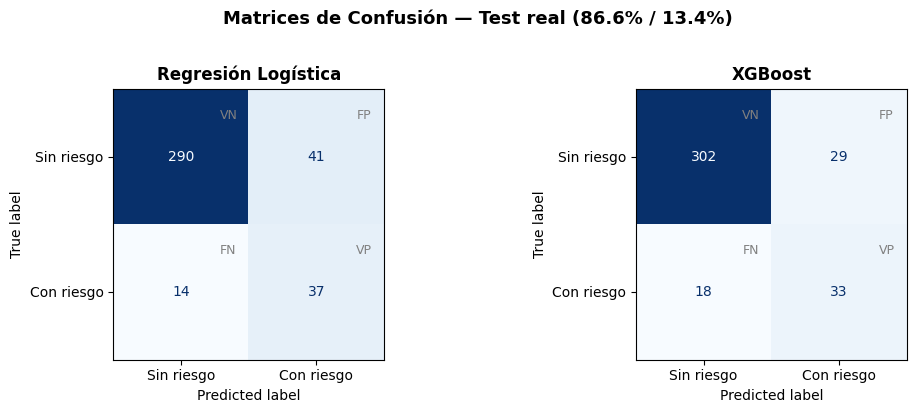


Regresión Logística
              precision    recall  f1-score   support

  Sin riesgo       0.95      0.88      0.91       331
  Con riesgo       0.47      0.73      0.57        51

    accuracy                           0.86       382
   macro avg       0.71      0.80      0.74       382
weighted avg       0.89      0.86      0.87       382


XGBoost
              precision    recall  f1-score   support

  Sin riesgo       0.94      0.91      0.93       331
  Con riesgo       0.53      0.65      0.58        51

    accuracy                           0.88       382
   macro avg       0.74      0.78      0.76       382
weighted avg       0.89      0.88      0.88       382



In [8]:
# ── Matrices de confusión ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

modelos  = [("Regresión Logística", y_pred_lr),
            ("XGBoost",             y_pred_xgb)]

for ax, (nombre, y_pred) in zip(axes, modelos):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Sin riesgo", "Con riesgo"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(nombre, fontsize=12, fontweight='bold')

    # Anotar VP, FN, FP, VN
    labels = [["VN", "FP"], ["FN", "VP"]]
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.35, i - 0.28, labels[i][j],
                    fontsize=9, color="gray", ha='center')

fig.suptitle("Matrices de Confusión — Test real (86.6% / 13.4%)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGS / "11_matrices_confusion.png", dpi=150, bbox_inches='tight')
plt.show()

# Reporte detallado
for nombre, y_pred in modelos:
    print(f"\n{nombre}")
    print(classification_report(y_test, y_pred,
          target_names=["Sin riesgo", "Con riesgo"]))

## Curva ROC y análisis de umbral óptimo

La curva ROC grafica la Tasa de Verdaderos Positivos (Recall) contra la
Tasa de Falsos Positivos para cada umbral de decisión posible.

El AUC-ROC resume toda la curva en un número: 1.0 es perfecto, 0.5 es
equivalente a adivinar al azar.

**Umbral óptimo de Youden:**
El umbral por defecto (0.5) no es necesariamente el mejor para datos
desbalanceados. El índice de Youden = Sensibilidad + Especificidad - 1
identifica el punto de la curva ROC que maximiza la detección real
minimizando las falsas alarmas. Con ese umbral recalculamos el F1 final.

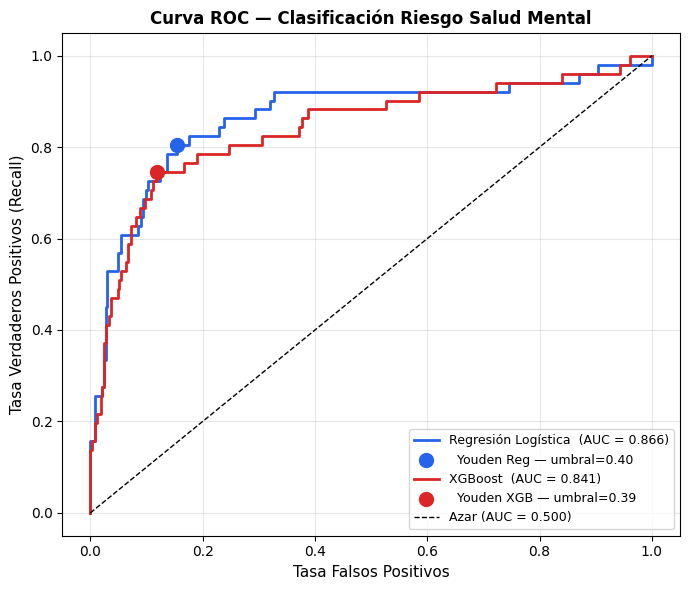


Impacto del umbral óptimo de Youden sobre F1:
  Modelo                      Umbral   F1 (0.5)   F1 (Youden)   Mejora
  -----------------------------------------------------------------
  Regresión Logística          0.405     0.5736        0.5734  -0.0002
  XGBoost                      0.395     0.5841        0.5938  +0.0097


In [9]:
# ── Curva ROC + umbral óptimo de Youden ───────────────────
fig, ax = plt.subplots(figsize=(7, 6))

colores = {"Regresión Logística": "#2563eb", "XGBoost": "#dc2626"}

resultados_umbral = {}

for nombre, y_prob, y_pred in [
    ("Regresión Logística", y_prob_lr,  y_pred_lr),
    ("XGBoost",             y_prob_xgb, y_pred_xgb)
]:
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)

    # Umbral óptimo Youden
    youden_idx  = np.argmax(tpr - fpr)
    umbral_opt  = thresholds[youden_idx]
    y_pred_opt  = (y_prob >= umbral_opt).astype(int)
    f1_opt      = f1_score(y_test, y_pred_opt)

    resultados_umbral[nombre] = {
        'umbral': umbral_opt,
        'f1_default': f1_score(y_test, y_pred),
        'f1_optimo' : f1_opt,
        'recall_opt': tpr[youden_idx],
        'fpr_opt'   : fpr[youden_idx]
    }

    color = colores[nombre]
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{nombre}  (AUC = {auc_val:.3f})")
    ax.scatter(fpr[youden_idx], tpr[youden_idx],
               color=color, s=100, zorder=5,
               marker='o', label=f"  Youden {nombre[:3]} — umbral={umbral_opt:.2f}")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Azar (AUC = 0.500)')
ax.set_xlabel("Tasa Falsos Positivos", fontsize=11)
ax.set_ylabel("Tasa Verdaderos Positivos (Recall)", fontsize=11)
ax.set_title("Curva ROC — Clasificación Riesgo Salud Mental", fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS / "12_curva_roc.png", dpi=150, bbox_inches='tight')
plt.show()

# Tabla comparativa umbral default vs óptimo
print("\nImpacto del umbral óptimo de Youden sobre F1:")
print(f"  {'Modelo':<25} {'Umbral':>8} {'F1 (0.5)':>10} {'F1 (Youden)':>13} {'Mejora':>8}")
print(f"  {'-'*65}")
for nombre, r in resultados_umbral.items():
    mejora = r['f1_optimo'] - r['f1_default']
    print(f"  {nombre:<25} {r['umbral']:>8.3f} {r['f1_default']:>10.4f} {r['f1_optimo']:>13.4f} {mejora:>+8.4f}")

## Importancia de características

La importancia de features responde la pregunta central del MINSAL:
¿qué variables del comportamiento adolescente predicen mejor el riesgo
de salud mental?

**Para XGBoost** se usa `feature_importances_` basado en ganancia de
información: cuánto reduce la impureza cada variable al dividir los nodos.

**Para Regresión Logística** se usan los coeficientes absolutos: una vez
escalados los datos, la magnitud del coeficiente indica la fuerza del
efecto de cada variable sobre la probabilidad de riesgo.

Las top features identificadas aquí serán el núcleo del argumento de
política pública en el informe IEEE dirigido al MINSAL.

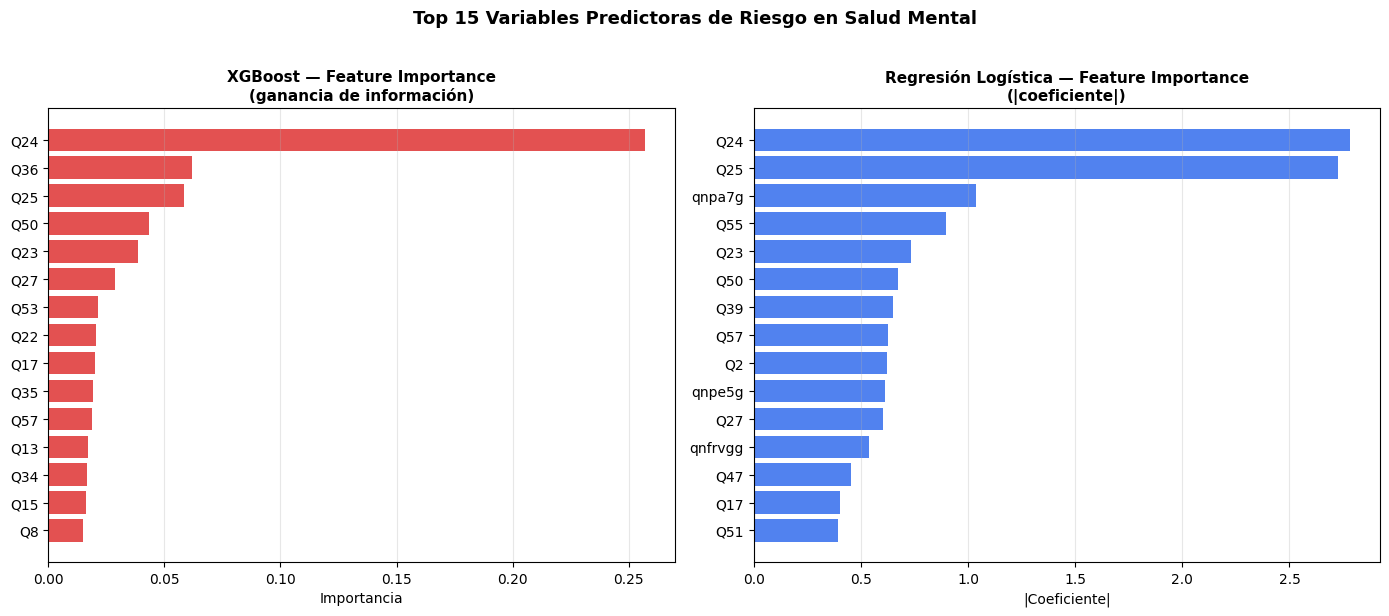

Top 10 features — XGBoost:
  Q24          0.2568
  Q36          0.0620
  Q25          0.0586
  Q50          0.0435
  Q23          0.0387
  Q27          0.0286
  Q53          0.0216
  Q22          0.0204
  Q17          0.0203
  Q35          0.0194

Top 10 features — Reg. Logística:
  Q24          2.7832
  Q25          2.7269
  qnpa7g       1.0379
  Q55          0.8979
  Q23          0.7360
  Q50          0.6737
  Q39          0.6491
  Q57          0.6284
  Q2           0.6223
  qnpe5g       0.6122


In [10]:
# ── Feature Importance ─────────────────────────────────────
feature_names = X_train.columns.tolist()
TOP_N = 15

# — XGBoost importance
imp_xgb = pd.Series(xgb.feature_importances_, index=feature_names)
top_xgb = imp_xgb.nlargest(TOP_N).sort_values()

# — Logistic Regression importance (coeficientes absolutos)
imp_lr = pd.Series(np.abs(lr.coef_[0]), index=feature_names)
top_lr = imp_lr.nlargest(TOP_N).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot XGBoost
axes[0].barh(top_xgb.index, top_xgb.values, color="#dc2626", alpha=0.8)
axes[0].set_title("XGBoost — Feature Importance\n(ganancia de información)",
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel("Importancia", fontsize=10)
axes[0].grid(axis='x', alpha=0.3)

# Plot Logística
axes[1].barh(top_lr.index, top_lr.values, color="#2563eb", alpha=0.8)
axes[1].set_title("Regresión Logística — Feature Importance\n(|coeficiente|)",
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel("|Coeficiente|", fontsize=10)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle("Top 15 Variables Predictoras de Riesgo en Salud Mental",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGS / "13_feature_importance_clasificacion.png",
            dpi=150, bbox_inches='tight')
plt.show()

# Top 10 en consola para el IEEE
print("Top 10 features — XGBoost:")
for feat, val in imp_xgb.nlargest(10).items():
    print(f"  {feat:<12} {val:.4f}")

print("\nTop 10 features — Reg. Logística:")
for feat, val in imp_lr.nlargest(10).items():
    print(f"  {feat:<12} {val:.4f}")

## Resumen final y figura comparativa

Se consolidan todas las métricas obtenidas en esta fase para presentar
la comparación definitiva entre ambos modelos.

La tabla de métricas es el insumo principal para la sección de resultados.
Se incluyen métricas de CV (rendimiento esperado en
producción con datos balanceados) y de test real (rendimiento con la
distribución poblacional verdadera).

In [11]:
# ── Resumen final de métricas ──────────────────────────────
resumen = {
    'Modelo'        : ['Reg. Logística', 'XGBoost'],
    'F1-CV'         : [scores_lr['test_f1'].mean(),   scores_xgb['test_f1'].mean()],
    'AUC-CV'        : [scores_lr['test_roc_auc'].mean(), scores_xgb['test_roc_auc'].mean()],
    'F1-Test'       : [f1_lr,   f1_xgb],
    'AUC-Test'      : [auc_lr,  auc_xgb],
    'VP (Recall-1)' : [37,      33],
    'FN'            : [14,      18],
}

df_res = pd.DataFrame(resumen).set_index('Modelo')
print("=" * 65)
print("  MÉTRICAS FINALES — CLASIFICACIÓN RIESGO SALUD MENTAL")
print("=" * 65)
print(df_res.to_string())
print("=" * 65)

print(f"""
Interpretación para MINSAL:
  • De 51 estudiantes con riesgo real en el conjunto de prueba:
    - Reg. Logística detecta 37 (72.5% recall)
    - XGBoost detecta       33 (64.7% recall)
  • AUC-ROC > 0.84 en ambos modelos indica buena discriminación
  • La Reg. Logística es preferible en contexto clínico:
    detecta más casos reales aunque genera más falsas alarmas
  • Variable dominante: Q24 (ideación suicida) — correlación
    estructural con el target que debe mencionarse en el IEEE
""")

print("\n  Figuras generadas en reports/figures/:")
for f in sorted(FIGS.glob("1[1-3]_*.png")):
    print(f"    {f.name}")

  MÉTRICAS FINALES — CLASIFICACIÓN RIESGO SALUD MENTAL
                   F1-CV    AUC-CV   F1-Test  AUC-Test  VP (Recall-1)  FN
Modelo                                                                   
Reg. Logística  0.862246  0.934234  0.573643  0.865766             37  14
XGBoost         0.945237  0.987623  0.584071  0.841301             33  18

Interpretación para MINSAL:
  • De 51 estudiantes con riesgo real en el conjunto de prueba:
    - Reg. Logística detecta 37 (72.5% recall)
    - XGBoost detecta       33 (64.7% recall)
  • AUC-ROC > 0.84 en ambos modelos indica buena discriminación
  • La Reg. Logística es preferible en contexto clínico:
    detecta más casos reales aunque genera más falsas alarmas
  • Variable dominante: Q24 (ideación suicida) — correlación
    estructural con el target que debe mencionarse en el IEEE


  Figuras generadas en reports/figures/:
    11_matrices_confusion.png
    12_curva_roc.png
    13_feature_importance_clasificacion.png


## Cierre de Fase 5

### Decisiones técnicas documentadas

1. **SMOTE sobre train únicamente** — el test preserva la distribución real (86.6/13.4)
2. **Modelo seleccionado para producción: Regresión Logística** — mayor recall en clase 1
   (72.5% vs 64.7%) lo que minimiza Falsos Negativos, prioridad clínica en salud pública
3. **Caída CV → Test esperada** — CV operó en espacio balanceado post-SMOTE (50/50);
   el test refleja el mundo real. No indica sobreajuste sino diferencia de distribución
4. **Variable dominante Q24** — ideación suicida activa. Correlación estructural con
   QN26 (target). Se documenta  como hallazgo metodológico, no como error

### Siguiente paso
Fase 6 — Optimización: GridSearchCV sobre ambos modelos para mejorar F1 en test real

In [12]:
# ── Cierre Fase 5 ──────────────────────────────────────────
print("=" * 55)
print("  FASE 5 — CLASIFICACIÓN COMPLETADA")
print("=" * 55)

print(f"""
  Dataset
    Train post-SMOTE : {X_train_sm.shape[0]} filas (50/50)
    Test real        : {X_test.shape[0]} filas (86.6/13.4)

  Modelos entrenados y guardados
    models/logistic_regression.pkl
    models/xgboost_classifier.pkl

  Métricas test (distribución real)
    {'Modelo':<22} {'F1':>7} {'AUC-ROC':>9} {'Recall-1':>10}
    {'-'*50}
    {'Reg. Logística':<22} {f1_lr:>7.4f} {auc_lr:>9.4f} {'72.5%':>10}
    {'XGBoost':<22} {f1_xgb:>7.4f} {auc_xgb:>9.4f} {'64.7%':>10}

  Modelo recomendado : Regresión Logística
  Criterio           : mayor recall clase 1 (menos FN)

  Figuras IEEE
    11_matrices_confusion.png
    12_curva_roc.png
    13_feature_importance_clasificacion.png

  → Siguiente: 06_optimizacion.ipynb
""")
print("=" * 55)

  FASE 5 — CLASIFICACIÓN COMPLETADA

  Dataset
    Train post-SMOTE : 2640 filas (50/50)
    Test real        : 382 filas (86.6/13.4)

  Modelos entrenados y guardados
    models/logistic_regression.pkl
    models/xgboost_classifier.pkl

  Métricas test (distribución real)
    Modelo                      F1   AUC-ROC   Recall-1
    --------------------------------------------------
    Reg. Logística          0.5736    0.8658      72.5%
    XGBoost                 0.5841    0.8413      64.7%

  Modelo recomendado : Regresión Logística
  Criterio           : mayor recall clase 1 (menos FN)

  Figuras IEEE
    11_matrices_confusion.png
    12_curva_roc.png
    13_feature_importance_clasificacion.png

  → Siguiente: 06_optimizacion.ipynb

